# Week2_ex3_to_5_analysis - Field through ring coils vs. the infinite-wire formula

![Week2_ex3 / Week2_ex4 result](Images/Week2_ex3_result_image.png)

A 400 mm copper wire (10 mm diameter) carries 100 A at 10 Hz along x. Its ends touch the region's x faces, so it acts like an infinitely long wire. Two copper rings (outer radius 20 mm) lie flat in the z = 0 plane at d = 100 mm (ring_2) and d = 300 mm (ring_1) from the wire, and `coil1_H` / `coil2_H` are the mean of H·n over a 20 mm disk on each ring.

Week2_ex4 and Week2_ex5 use the same wire, region and mesh settings, so they are checked here as well instead of in separate notebooks. Week2_ex4 reads the same two disks as the mean of B·n, and Week2_ex5 moves ring_2 out to d = 600 mm and reports the flux (the integral of B·n) through each disk.

This is a short check, not a hypothesis-driven dive. The disk average of Ampere's 1/r field has a closed form, so the FEM values can be compared directly. At 10 Hz the skin depth in copper (~21 mm) is much larger than the wire radius (5 mm), so the current is uniform and the DC formula still applies.

$$\langle H_z \rangle = \frac{1}{\pi a^2}\iint_{disk} \frac{I}{2\pi r}\,dA = \frac{I}{2\pi}\cdot\frac{2\left(d-\sqrt{d^2-a^2}\right)}{a^2} \quad (d > a)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
# 1. Model values (current is the peak amplitude, so the Phase = 0deg result is the peak field)
I = 100.0      # A
a = 0.020      # disk radius, m
d = np.array([0.100, 0.300])   # distance from the wire to each disk center, m

# 2. FEM values, read once from Calculator Expressions Table 1 in the AEDT GUI (Setup1 : LastAdaptive, Phase = 0deg)
# The minus sign only comes from the disk normal pointing +z while H points -z on this side of the wire, so compare magnitudes
H_fem = np.abs(np.array([-160.237384, -52.896619]))

# 3. Exact disk average vs. the plain field at the disk center
H_disk = I / (2 * np.pi) * 2 * (d - np.sqrt(d**2 - a**2)) / a**2
H_center = I / (2 * np.pi * d)

pd.DataFrame({
    "Ring": ["ring_2 (coil2_H)", "ring_1 (coil1_H)"],
    "d [mm]": d * 1e3,
    "FEM [A/m]": H_fem,
    "Disk average [A/m]": H_disk.round(3),
    "Center value [A/m]": H_center.round(3),
    "Error vs disk avg [%]": ((H_fem - H_disk) / H_disk * 100).round(3),
    "Error vs center [%]": ((H_fem - H_center) / H_center * 100).round(3),
})


,Ring,d [mm],FEM [A/m],Disk average [A/m],Center value [A/m],Error vs disk avg [%],Error vs center [%]
0,ring_2 (coil2_H),100.0,160.237384,160.779,159.155,-0.337,0.680
1,ring_1 (coil1_H),300.0,52.896619,53.111,53.052,-0.403,-0.292


In [3]:
# 4. Ratio between the two rings -- independent of the current definition and the normal's sign
ratio_fem = H_fem[0] / H_fem[1]
ratio_theory = H_disk[0] / H_disk[1]

pd.DataFrame({
    "coil2_H / coil1_H": ["FEM", "Disk average"],
    "Value": [round(ratio_fem, 4), round(ratio_theory, 4)],
    "Error [%]": [round((ratio_fem - ratio_theory) / ratio_theory * 100, 3), 0.0],
})


,coil2_H / coil1_H,Value,Error [%]
0,FEM,3.0293,0.066
1,Disk average,3.0272,0.000


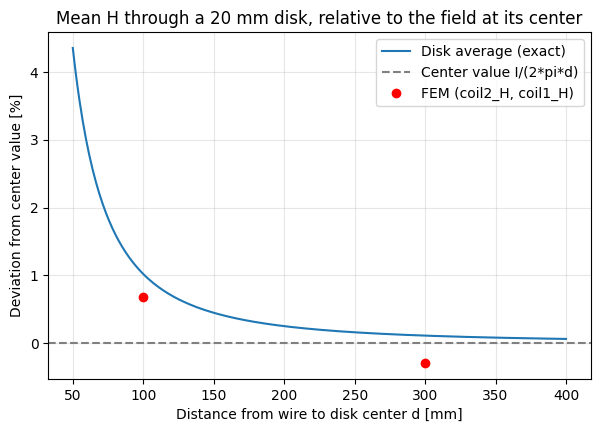

In [4]:
# 5. Deviation from the center value -- shows how much the finite disk size matters at each distance
d_line = np.linspace(0.05, 0.40, 300)
H_disk_line = I / (2 * np.pi) * 2 * (d_line - np.sqrt(d_line**2 - a**2)) / a**2
H_center_line = I / (2 * np.pi * d_line)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(d_line * 1e3, (H_disk_line / H_center_line - 1) * 100, label="Disk average (exact)")
ax.axhline(0, color="gray", linestyle="--", label="Center value I/(2*pi*d)")
ax.plot(d * 1e3, (H_fem / H_center - 1) * 100, "o", color="red", label="FEM (coil2_H, coil1_H)")
ax.set_xlabel("Distance from wire to disk center d [mm]")
ax.set_ylabel("Deviation from center value [%]")
ax.set_title("Mean H through a 20 mm disk, relative to the field at its center")
ax.grid(True, alpha=0.3)
ax.legend()

os.makedirs("Images", exist_ok=True)
plt.savefig("Images/Week2_ex3_disk_average_deviation.png", dpi=150, bbox_inches="tight")
plt.show()


## Week2_ex4 - the same disks read as B

Week2_ex4 is the ex3 model with `Vector_H` swapped for `Vector_B` in the named expressions. Everything outside the wire is vacuum, so B = μ0·H holds exactly inside the FEM solution, and the ex4 values should just be the ex3 values times μ0. This is not an independent check of the physics, only a check that the B output path agrees with the H one. The values were read once from Calculator Expressions Table 1 in the Week2_ex4 project, with the report expression multiplied by 1e9 so the table shows enough digits.

In [5]:
# 6. Week2_ex4 FEM values, in the same order as above (ring_2 first, then ring_1)
# The report showed coil_B * 1e9, so scale it back to tesla
mu0 = 4e-7 * np.pi
B_fem = np.abs(np.array([-201359.898412, -66471.741752])) * 1e-9

pd.DataFrame({
    "Ring": ["ring_2 (coil2_B)", "ring_1 (coil1_B)"],
    "d [mm]": d * 1e3,
    "FEM B [uT]": (B_fem * 1e6).round(5),
    "mu0 * FEM H [uT]": (mu0 * H_fem * 1e6).round(5),
    "Difference [ppm]": ((B_fem / (mu0 * H_fem) - 1) * 1e6).round(2),
})

,Ring,d [mm],FEM B [uT],mu0 * FEM H [uT],Difference [ppm]
0,ring_2 (coil2_B),100.0,201.35990,201.36024,-1.67
1,ring_1 (coil1_B),300.0,66.47174,66.47185,-1.66


## Week2_ex5 - flux through a ring moved out to d = 600 mm

![Week2_ex5 result](Images/Week2_ex5_result_image.png)

Week2_ex5 keeps ring_1 at d = 300 mm but moves ring_2 out to d = 600 mm, and integrates B·n over each disk instead of averaging it. The region is still ±800 mm in y, so ring_2's center is only 200 mm from the radiation boundary, while the ex3 rings were at least 500 mm away. Week2_ex1 showed that a radiation boundary close to the field point pulls the field down, so the expectation before reading the values was that coil2_phi comes out low and the coil1/coil2 ratio lands above the ideal value of about 2.

In [6]:
# 7. Week2_ex5 FEM values (the report expression was multiplied by 1e9, so these were read in nWb)
d5 = np.array([0.300, 0.600])   # ring_1, ring_2
phi_fem = np.abs(np.array([-82.5857677720, -38.7673032160])) * 1e-9

# 8. Ideal flux = mu0 * (exact disk average of H) * (exact disk area)
H_disk5 = I / (2 * np.pi) * 2 * (d5 - np.sqrt(d5**2 - a**2)) / a**2
phi_theory = mu0 * H_disk5 * np.pi * a**2

pd.DataFrame({
    "Ring": ["ring_1 (coil1_phi)", "ring_2 (coil2_phi)"],
    "d [mm]": d5 * 1e3,
    "FEM [nWb]": (phi_fem * 1e9).round(4),
    "Theory [nWb]": (phi_theory * 1e9).round(4),
    "Error [%]": ((phi_fem - phi_theory) / phi_theory * 100).round(3),
})

,Ring,d [mm],FEM [nWb],Theory [nWb],Error [%]
0,ring_1 (coil1_phi),300.0,82.5858,83.8691,-1.530
1,ring_2 (coil2_phi),600.0,38.7673,41.8995,-7.476


ring_2 comes out low as expected, but ring_1 is also off by about 1.5%, even though it sits exactly where it did in ex3, where the error was only 0.4%. The boundary is the same as in ex3, so it can't explain the extra 1.1%. The difference is Integrate vs. Mean: Mean divides by the disk area, so any error in the meshed area cancels out, but Integrate uses the meshed area as it is. Integrating the constant 1 over `field_circle_1` in the Fields Calculator gives that meshed area directly.

In [7]:
# 9. Meshed disk area, read from Integrate(Surface(field_circle_1), 1) in the Fields Calculator
A_mesh = 0.0012423314164921
A_exact = np.pi * a**2
A_24gon = 12 * a**2 * np.sin(np.radians(15))   # regular 24-sided polygon inside the circle

pd.DataFrame({
    "Area": ["Exact circle", "Regular 24-gon", "Meshed disk (FEM)"],
    "Value [mm^2]": (np.array([A_exact, A_24gon, A_mesh]) * 1e6).round(6),
    "vs exact circle [%]": ((np.array([A_exact, A_24gon, A_mesh]) / A_exact - 1) * 100).round(4),
})

,Area,Value [mm^2],vs exact circle [%]
0,Exact circle,1256.637061,0.0000
1,Regular 24-gon,1242.331416,-1.1384
2,Meshed disk (FEM),1242.331416,-1.1384


In [8]:
# 10. Divide the FEM flux by the meshed area to get the mean B, then compare with the exact disk average
# Only field_circle_1 was measured; field_circle_2 has the same radius and settings, so the same area is assumed
B_mean5 = phi_fem / A_mesh
B_disk5 = mu0 * H_disk5

pd.DataFrame({
    "Ring": ["ring_1 (coil1_phi)", "ring_2 (coil2_phi)"],
    "d [mm]": d5 * 1e3,
    "Error, raw flux [%]": ((phi_fem - phi_theory) / phi_theory * 100).round(3),
    "Error, area-corrected [%]": ((B_mean5 - B_disk5) / B_disk5 * 100).round(3),
})

,Ring,d [mm],"Error, raw flux [%]","Error, area-corrected [%]"
0,ring_1 (coil1_phi),300.0,-1.530,-0.396
1,ring_2 (coil2_phi),600.0,-7.476,-6.410


In [9]:
# 11. Ratio between the two rings -- the disk area cancels out here, so this number doesn't depend on the area correction
ratio_fem5 = phi_fem[0] / phi_fem[1]
ratio_theory5 = H_disk5[0] / H_disk5[1]

pd.DataFrame({
    "coil1_phi / coil2_phi": ["FEM", "Disk average"],
    "Value": [round(ratio_fem5, 4), round(ratio_theory5, 4)],
    "Error [%]": [round((ratio_fem5 - ratio_theory5) / ratio_theory5 * 100, 3), 0.0],
})

,coil1_phi / coil2_phi,Value,Error [%]
0,FEM,2.1303,6.426
1,Disk average,2.0017,0.000


## Conclusion

**Week2_ex3.** Both rings land within 0.5% of the exact disk average (-0.34% at 100 mm, -0.40% at 300 mm), and the ring-to-ring ratio matches to about 0.07%. At d = 100 mm the disk average sits about 1% above the center value, and the FEM result is closer to the disk average (-0.34%) than to the center value (+0.68%). So the finite disk size shows up in the FEM, just with a small offset on top. That offset is almost the same at both rings, so it looks like a uniform sub-percent bias from the adaptive mesh rather than anything distance-dependent. With the boundary 800 mm away in y and z, its effect is basically gone at these two distances.

**Week2_ex4.** The B values equal μ0 times the ex3 H values to within 2 ppm at both rings, with the same offset at each. The two exercises read the same solution, so this only confirms that the B output path is consistent with the H one.

**Week2_ex5.** The raw flux has two separate errors on top of each other. The first is the meshed disk area: `field_circle_1` is meshed as an exact regular 24-gon (15° steps), which is 1.14% smaller than the true circle, and Integrate carries that straight into the flux. After dividing by the meshed area, ring_1 is at -0.40%, the same as ex3 at the same spot. The second is the radiation boundary: ring_2, only 200 mm from the boundary, is still 6.4% low after the area correction, and the coil1/coil2 ratio comes out 2.130 instead of 2.002. The ratio does not depend on the area correction at all, so the boundary effect holds either way. This is the same mechanism Week2_ex1 found, showing up in a different geometry and a different quantity. The "roughly half" expectation in the original notebook only holds if the region is made larger compared to 600 mm. No further analysis is needed for these three exercises.